In [115]:
## Firstly do PCA for FPOCalCu, do projections 
## Secondly do PCA for all regions to see if interesting regions show up

## LM to verify stats

## Boxplot for pca projections of Atril and UKB to SCA2+ctl (Biosca+Cermoi)
## Normative space mapping

## Some todo experiments with automatic parameter selection

In [3]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.formula.api as smf
import os

In [5]:
curProject = 'ataxia'
curRoot = 'C'  # 'C' or 'D'

In [7]:
#######################   read in all_DB_info csv   ########################
infoBaselineName = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\processed_INFO\ATRIL_BIOSCA_CERMOI_time1_only.csv'
Atril_Biosca_Cermoi_INFO = pd.read_csv(infoBaselineName,index_col=0,header=0)

#print("combined_iso_u columns:", combined_iso_u.columns.tolist())
print("INFO columns:", Atril_Biosca_Cermoi_INFO.columns.tolist())

### verification of column names ###
#one_iso_u_name = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_iso_u\FColl-SRh_left_name06-43-43--210_embeddings_iso_u.csv'
#one_combined_iso_u = pd.read_csv(one_iso_u_name,index_col=0,header=0)
#print("region columns:", one_combined_iso_u.columns.tolist())

INFO columns: ['RANDOMIZATION', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS', 'CodeICM', 'Age_onset', 'CCFS', 'Handedness', 'Disease_duration', 'allele1', 'allele2', 'minAllele', 'maxAllele', 'sumAllele']


In [9]:
#######################################  performing PCA  #########################################
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def perform_pca(dist_df, numDim):
    """
    Performs PCA on a dataframe of descriptors. 
    Always uses Euclidean distance by its nature, highly stable for small samples.
    """
    subjNames = dist_df.index
    dimNames = np.arange(1, numDim + 1)
    columns = [f"pca_dim{i}" for i in dimNames]
    
    # Standardize the data (Crucial for PCA), each of the descriptors has a mean of 0 and variance of 1
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(dist_df.values)
    
    # Initialize and Run PCA
    pca_model = PCA(n_components=numDim)
    pca_values = pca_model.fit_transform(X_scaled)
    
    # Create DataFrame
    pca_DF = pd.DataFrame(pca_values, index=subjNames, columns=columns)
    
    # Attach metadata: Explained Variance Ratio, how much "information" is captured in the numDim dimensions
    explained_var = pca_model.explained_variance_ratio_.sum()
    pca_DF.attrs['explained_variance'] = explained_var
    
    print(f"Total Explained Variance (3 dims): {explained_var:.2%}")
    
    return pca_DF

In [11]:
##############  projecting target_matrix into the PCA space of the refernece_matrix  ################

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def project_to_pca_space(reference_matrix, target_matrix, n_components=6):
    """
    Creates a PCA space from a reference set (e.g., Study 1 + 2) 
    and projects a new set (e.g., Study 3) into that same space.
    
    Parameters:
    -----------
    reference_matrix : np.array (Samples x Features)
        The data used to 'build' the PCA coordinate system.
    target_matrix : np.array (Samples x Features)
        The new data to be projected into the established system.
    n_components : int
        Number of PCA dimensions to return.
        
    Returns:
    --------
    ref_pca : np.array
        Reference data in the new PCA space.
    target_pca : np.array
        Target data projected into the same PCA space.
    pca_model : sklearn.decomposition.PCA
        The fitted PCA object (useful for checking explained variance).
    """
    columns = [f'pca_dim{i+1}' for i in range(n_components)]
    
    # 1. Scaling is crucial for PCA
    scaler = StandardScaler()    
    ref_scaled = scaler.fit_transform(reference_matrix)   # Fit the scaler ONLY on the reference data
    target_scaled = scaler.transform(target_matrix)       # Apply the SAME scaling to the target data
    
    # 2. Initialize and Fit PCA on the reference data
    pca = PCA(n_components=n_components)
    ref_pca = pca.fit_transform(ref_scaled)
    ref_pca_DF = pd.DataFrame(ref_pca, index=reference_matrix.index, columns=columns) # Change numphy array to df
    
    # 3. Project target data into the EXISTING PCA space
    target_pca = pca.transform(target_scaled)        # IMPORTANT: We use .transform(), NOT .fit_transform() here
    target_pca_DF = pd.DataFrame(target_pca, index=target_matrix.index, columns=columns)
    
    return ref_pca_DF, target_pca_DF, pca

In [13]:
##################  merging the above two functions pca and projection into one  ###################
##### perform PCA on the ref_df, then project the target_df into the ref_df space #####

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def run_pca_workflow(ref_df, target_df=None, n_components=6):
    """
    Unified PCA handler. 
    If target_df is None: Performs standard PCA on ref_df.
    If target_df exists: Fits PCA on ref_df and projects target_df into that space.
    """
    # 0. ENSURE COLUMN ALIGNMENT (The silent PCA killer). This ensures Feature A is always in the same 'slot'
    # Sorts the columns alphabetically (e.g., A-Z). 
    # By doing this to both DataFrames, we guarantee that a given feature is in the same slot for both, 
    # even if the original CSV files had different column orders
    ref_df = ref_df.sort_index(axis=1)
    
    columns = [f'pca_dim{i+1}' for i in range(n_components)]
    
    # 1. Scaling - Always fit only on the Reference
    scaler = StandardScaler()
    ref_scaled = scaler.fit_transform(ref_df)
    
    # 2. PCA Fit - Always fit only on the Reference
    pca_model = PCA(n_components=n_components)
    ref_pca_vals = pca_model.fit_transform(ref_scaled)
    
    # Convert to DataFrame
    ref_pca_df = pd.DataFrame(ref_pca_vals, index=ref_df.index, columns=columns) # Change numphy array to df
    
    # 3. Handle Projection (if target exists)
    if target_df is not None:
        print('Target_df not None, calculating projection!')
        target_df = target_df.sort_index(axis=1) # Sort columns to match ref
        target_scaled = scaler.transform(target_df) # Use ref's scaler
        target_pca_vals = pca_model.transform(target_scaled) # Use ref's PCA
        target_pca_df = pd.DataFrame(target_pca_vals, index=target_df.index, columns=columns) # Change numphy array to df
        # Combine them
        combined_pca = pd.concat([ref_pca_df, target_pca_df])
        return combined_pca, pca_model
    
    return ref_pca_df, pca_model

In [ ]:
################################################    generation of Isomap    ###############################################
from sklearn.manifold import Isomap

def perform_isomap(dist,numDim,numNeig,metric='euclidean'):
    subjNames = dist.index
    dimNames = np.arange(1,numDim+1)
    columns = [f"iso_dim{i}_neig{numNeig}" for i in dimNames]
    #print(columns)    

    dist_centered = dist.copy()
    if metric != 'precomputed':
        dist_centered = dist.values - dist.values.mean(axis=0)
    iso = Isomap(n_neighbors=numNeig,n_components=numDim,metric=metric).fit_transform(dist_centered)
    iso_DF = pd.DataFrame(iso,index=subjNames,columns=columns)    
    return iso_DF
    
def perform_region_isomap(dist,numDim_iso,numNeig_list_iso,curRegion,writeIsomap,metric='euclidean'):
    iso = pd.DataFrame(index=dist.index)
    print('Generating isomaps.')
    for numNeig in numNeig_list_iso:
        iso_cur = perform_isomap(dist,numDim_iso,numNeig,metric=metric)
        # add to existing df
        iso_DF = pd.DataFrame(iso_cur, index=iso.index)
        iso = pd.concat([iso, iso_DF], axis=1)
    if writeIsomap:  # SAVE Isomaps as csv, for debug
        outName = 'iso_'+curRegion+'_dim_'+str(numDim_iso)+'_neig_'+str(numNeig_list_iso)+'.csv'
        outFileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_iso_u\{outName}'
        print(outFileName)
        iso.to_csv(outFileName,index_label='subjID')
    return iso

In [ ]:
###############################   generation of UMAP   ################################
import umap
import random
# to ensure that the results are always the same
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def perform_UMAP(df,n_comp,n_neighbors,min_dist):
    reducer = umap.UMAP(n_components=n_comp,n_neighbors=n_neighbors,min_dist=min_dist,random_state=SEED)
    embedding = reducer.fit_transform(df)

    columns = []    
    if n_comp == 1:    # Column naming logic
        columns = [f'u_dim{n_comp}_neig{n_neighbors}']
    elif n_comp == 2:
        columns = [f'u_dim{n_comp}_1_neig{n_neighbors}', f'u_dim{n_comp}_2_neig{n_neighbors}']
    else:
        columns = [f'u_dim{n_comp}_{i}_neig{n_neighbors}' for i in range(n_comp)]
    
    embedding_df = pd.DataFrame(embedding, columns=columns)   # Create a DataFrame for the embedding
    embedding_df.index = df.index
    return embedding_df

def perform_region_UMAP(dist,curRegion,numDim_u,numNeig_list_u,writeUMAP):
    umap_results = pd.DataFrame(index=dist.index)
    min_dist = 0.2                # Change this to the desired minimum distance
    print('Generating UMAPs.')
    for n_comp in numDim_u:
        for n_neighbors in numNeig_list_u:  # perform UMAP
            embedding_df = perform_UMAP(dist, n_comp, n_neighbors, min_dist)   # Call the helper function                     
            umap_results = pd.concat([umap_results, embedding_df], axis=1)    # Concatenate to our results dataframe
    if writeUMAP:  # SAVE Umap as csv, for debug
        outName = 'u_'+curRegion+'_dim_'+str(numDim_u)+'_neig_'+str(numNeig_list_u)+'.csv'
        outFileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_iso_u\{outName}'
        print(outFileName)
        umap_results.to_csv(outFileName,index_label='subjID')
    return umap_results

In [15]:
##########################  Define subject lists for distance selection  #############################
# Atril_Biosca_Cermoi_INFO defined above

# 1. Get the relevant subjects
sca_1_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 1) | \
            ((Atril_Biosca_Cermoi_INFO['SCA'] == 0) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'BIOSCA'))
sca_2_ctl = ((Atril_Biosca_Cermoi_INFO['SCA'] == 2) & (Atril_Biosca_Cermoi_INFO['CodeICM'] != 'ATRIL')) | \
            (Atril_Biosca_Cermoi_INFO['SCA'] == 0) 
sca_2_ctl_with_Atril = (Atril_Biosca_Cermoi_INFO['SCA'] == 2) | (Atril_Biosca_Cermoi_INFO['SCA'] == 0)   # All sca2 subjects, Atril included
sca_2_ATRIL = (Atril_Biosca_Cermoi_INFO['SCA'] == 2) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'ATRIL')  # sca2 subjects of Atril only
sca_3_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 3) | \
            ((Atril_Biosca_Cermoi_INFO['SCA'] == 0) & (Atril_Biosca_Cermoi_INFO['CodeICM'] == 'BIOSCA'))
sca_7_ctl = (Atril_Biosca_Cermoi_INFO['SCA'] == 7) | (Atril_Biosca_Cermoi_INFO['SCA'] == 0) 

# 2. Use the condition to get the index (subject names)
subjects_sca_1_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_1_ctl].index.tolist()
#print(subjects_sca_1_ctl)
subjects_sca_2_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_2_ctl].index.tolist()
print(subjects_sca_2_ctl)
subjects_sca_2_ctl_with_Atril = Atril_Biosca_Cermoi_INFO.loc[sca_2_ctl_with_Atril].index.tolist()
print(subjects_sca_2_ctl_with_Atril
     )
subjects_sca_2_ATRIL = Atril_Biosca_Cermoi_INFO.loc[sca_2_ATRIL].index.tolist()
subjects_sca_3_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_3_ctl].index.tolist()
#print(subjects_sca_3_ctl)
subjects_sca_7_ctl = Atril_Biosca_Cermoi_INFO.loc[sca_7_ctl].index.tolist()
#print(subjects_sca_7_ctl)


['001012FJ', '001015VJ', '001017VP', '001019DA', '001020HG', '001021CJ', '001022LM', '001025LJ', '001027RY', '001032SG', '001037GA', '001040BF', '001045PB', '001046CJ', '001049BD', '001054MP', '001055JC', '001057MB', '001058FG', '001059MV', '001060MJ', '001065BC', '001073PM', '001075HJ', '001078PM', '001079LP', '001085BN', '001086CP', '001091MR', '001099GL', '001100PY', '001101JO', '00001PJ', '00002PV', '00004PA', '00007OP', '00008CJ', '00009LN', '00011EG', '00012BM', '00017ML', '00019RP', '00020CT', '00021JA', '00022DA', '00023EA', '00025AY', '00026AD', '00027EF', '00029DP', '00030CA', '00031CP', '00032DL', '00035NR', '00036DC', '00037CI', '00039OV']
['0010001OP', '0010002MV', '0010003CJ', '0010004HV', '0010005BC', '0010006OG', '0010007MA', '0010008CT', '0010009BJ', '0010010DM', '0010011CP', '0010012MC', '0010013AN', '0010014MM', '0010015BV', '0010016VP', '0010017MD', '0010018RE', '0010019MM', '0010020PA', '0010021MA', '0010022MB', '0010023MM', '0010024VN', '0010025RA', '0010026DA', '

In [17]:
##########################  add the postfix to the subject name  #########################
## given the name_list, the time_step and the INFO file, add the appropriate postfix,
## returns the new_list
## Note that assuming using only V1 and V3 for CERMOI
def add_longitudinal_postfix(name_list, time_step, map_csv_path):
    # Load the map - ensure index is the Subject ID
    mapping_df = pd.read_csv(map_csv_path, index_col=0)
    
    # Define the postfix rules based on Study and Time
    # Modify add more studies or timepoints here
    rules = {
        'ATRIL':  {'time_1': 'M0', 'time_2': 'M12'},
        'BIOSCA': {'time_1': 'E1', 'time_2': 'E2'},
        'CERMOI': {'time_1': 'V1', 'time_2': 'V3'}
    }
    
    # Build the new list
    new_list = []
    
    # Create a dictionary of SubjectID -> CodeICM for fast lookup
    # Use .to_dict() to avoid repeated .loc calls inside the loop
    study_map = mapping_df['CodeICM'].to_dict()
    
    for name in name_list:
        # Get the study for this subject
        study = study_map.get(name)
        
        # Check if study exists and if we have a rule for this time_step
        if study in rules and time_step in rules[study]:
            postfix = rules[study][time_step]
            new_list.append(f"{name}_{postfix}")
        else:  # If subject not found or no rule exists, keep original name
            new_list.append(name)
            
    return new_list

In [19]:
################  construct the _withPostfix subject list by adding the postfix  ##################
## define the new lists with the postfix added, for the distance selection

#map_csv = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\subject_project_timeStep_map.csv' # missing subjects! Not used anymore
map_csv = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\processed_INFO\ATRIL_BIOSCA_CERMOI_time1_only.csv'

subjects_sca_1_ctl_withPostfix = add_longitudinal_postfix(subjects_sca_1_ctl, 'time_1', map_csv)
subjects_sca_2_ctl_withPostfix = add_longitudinal_postfix(subjects_sca_2_ctl, 'time_1', map_csv)
subjects_sca_2_Atril_withPostfix = add_longitudinal_postfix(subjects_sca_2_ATRIL, 'time_1', map_csv)
subjects_sca_2_ctl_with_Atril_withPostfix = add_longitudinal_postfix(subjects_sca_2_ctl_with_Atril, 'time_1', map_csv)

subjects_sca_3_ctl_withPostfix = add_longitudinal_postfix(subjects_sca_3_ctl, 'time_1', map_csv)
subjects_sca_7_ctl_withPostfix = add_longitudinal_postfix(subjects_sca_7_ctl, 'time_1', map_csv)
print(subjects_sca_2_ctl)
print(subjects_sca_2_Atril_withPostfix)

['001012FJ', '001015VJ', '001017VP', '001019DA', '001020HG', '001021CJ', '001022LM', '001025LJ', '001027RY', '001032SG', '001037GA', '001040BF', '001045PB', '001046CJ', '001049BD', '001054MP', '001055JC', '001057MB', '001058FG', '001059MV', '001060MJ', '001065BC', '001073PM', '001075HJ', '001078PM', '001079LP', '001085BN', '001086CP', '001091MR', '001099GL', '001100PY', '001101JO', '00001PJ', '00002PV', '00004PA', '00007OP', '00008CJ', '00009LN', '00011EG', '00012BM', '00017ML', '00019RP', '00020CT', '00021JA', '00022DA', '00023EA', '00025AY', '00026AD', '00027EF', '00029DP', '00030CA', '00031CP', '00032DL', '00035NR', '00036DC', '00037CI', '00039OV']
['0010001OP_M0', '0010002MV_M0', '0010003CJ_M0', '0010004HV_M0', '0010005BC_M0', '0010006OG_M0', '0010007MA_M0', '0010008CT_M0', '0010009BJ_M0', '0010010DM_M0', '0010011CP_M0', '0010012MC_M0', '0010013AN_M0', '0010014MM_M0', '0010015BV_M0', '0010016VP_M0', '0010017MD_M0', '0010018RE_M0', '0010019MM_M0', '0010020PA_M0', '0010021MA_M0', '00

In [80]:
###############  test and debug: the UKB projection  #################
in_name = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\UKB_FPO-SCu-ScCal_right_name07-15-26--174_embeddings_without_ID.csv'
df = pd.read_csv(in_name)
df.index = range(1, len(df) + 1)
df.index.name = 'ID'

#print(df.columns)
#print(df.head())

############### compare with a written Champollion file  #################
in_name_sca = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril\FPO-SCu-ScCal_right_name07-15-26--174_embeddings.csv'
df_sca = pd.read_csv(in_name_sca, index_col=0, header=0)
#df_sca = pd.read_csv(in_name_sca, index_col='ID')

#print(df_info.columns)
#print(df_info.head())

################  test pca projection  ################
pca_select, pca_model = run_pca_workflow(ref_df=df_sca, target_df=df, n_components=6)
#print(pca_select.index)
#print(pca_select.columns)
#print(pca_select.head)

################  test merge with INFO  ################
# Change line 25 to this:
# convert all index to string, add a Clean_ID column
pca_select['Clean_ID'] = pca_select.index.map(lambda x: str(x).rsplit('_', 1)[0])

# debug to make sure there are subject matches
matches = set(pca_select['Clean_ID']).intersection(set(Atril_Biosca_Cermoi_INFO.index))
print(f"Found {len(matches)} matching IDs out of {len(pca_select)} PCA rows.")

combined_pca_info = pd.merge(pca_select, Atril_Biosca_Cermoi_INFO, left_on='Clean_ID', right_index=True, how='outer')
print(combined_pca_info['CodeICM'].value_counts(dropna=False))
# Fill only the NaN values in the CodeICM column with 'UKB'
combined_pca_info['CodeICM'] = combined_pca_info['CodeICM'].fillna('UKB')

print(combined_pca_info['CodeICM'].value_counts(dropna=False))

Target_df not None, calculating projection!
Found 43 matching IDs out of 42478 PCA rows.
CodeICM
NaN       42435
BIOSCA       81
ATRIL        45
CERMOI       40
Name: count, dtype: int64
CodeICM
UKB       42435
BIOSCA       81
ATRIL        45
CERMOI       40
Name: count, dtype: int64


In [84]:
##########################  perform PCA and write out two versions, with and without the info  ########################
# NOTE: if the subjNames of the input is with the postfix, set subjName_with_postfix to True
# The Champollion was originally run where the output subjectID doesn't have the postfix
# The postfix is added later on before processing, so by default subjName_with_postfix is True

subjName_with_postfix = True
regions = ["FPO-SCu-ScCal_right_name07-15-26--174_embeddings"]  # define the region of interest
#regions = ["FPO-SCu-ScCal_left_name07-13-21--118_embeddings"]
sca = 302       # 2,7, 202 for projection of Atril to sca2 base, 302 for projection UKB to sca2 base
perform_pca_all_together = False      # not sca-specific
perform_pca_by_sca = False             # sca-specific, False if projection
perform_pca_projection = True        # True only when preforming projection

if sca == 1:
    subjects_select = subjects_sca_1_ctl
if sca == 2:
    subjects_select = subjects_sca_2_ctl
if sca == 3:
    subjects_select = subjects_sca_3_ctl
if sca == 7:
    subjects_select = subjects_sca_7_ctl  
if sca == 102:
    subjects_select = subjects_sca_2_ctl_with_Atril   
if sca == 202:
    base_subjects_select = subjects_sca_2_ctl 
    projection_subjects_select = subjects_sca_2_ATRIL  
if sca == 302:
    base_subjects_select = subjects_sca_2_ctl 
    projection_subjects_select = None      
if subjName_with_postfix:
    if sca == 1:
        subjects_select = subjects_sca_1_ctl_withPostfix
    if sca == 2:
        subjects_select = subjects_sca_2_ctl_withPostfix
    if sca == 3:
        subjects_select = subjects_sca_3_ctl_withPostfix
    if sca == 7:
        subjects_select = subjects_sca_7_ctl_withPostfix  
    if sca == 102:
        subjects_select = subjects_sca_2_ctl_with_Atril_withPostfix   
    if sca == 202:
        base_subjects_select = subjects_sca_2_ctl_withPostfix 
        projection_subjects_select = subjects_sca_2_Atril_withPostfix 
    if sca == 302:
        base_subjects_select = subjects_sca_2_ctl_withPostfix 
        projection_subjects_select = None         

infoBaselineName = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\processed_INFO\ATRIL_BIOSCA_CERMOI_time1_only.csv'
Atril_Biosca_Cermoi_INFO = pd.read_csv(infoBaselineName,index_col=0,header=0)
for curRegion in regions:
    dist_Atril, dist_Biosca, dist_Cermoi = None, None, None    
    distance_path_Atril = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril\{curRegion}.csv'
    distance_path_Biosca = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Biosca\{curRegion}.csv'
    distance_path_Cermoi = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Cermoi\{curRegion}.csv'

    ###########  define output file names for all SCA together  ###########
    if perform_pca_all_together:
        combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_all.csv'
        combined_pca_INFO_fileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
                                     rf'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_INFO.csv')
    ###########  define output file names for seperating SCAs  ###########    
    if (not perform_pca_all_together) & (sca != 202):
        combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_select_{sca}.csv'
        combined_pca_INFO_fileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
                                     fr'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_select_{sca}_INFO.csv')
    ###########  define output file names for Atril sca2 projection, seperating SCAs  ###########
    if (not perform_pca_all_together) & (sca == 202):
        combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_project_2AtrilToRest.csv'
        combined_pca_INFO_fileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
                                     rf'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2AtrilToRest_INFO.csv')
    ###########  define output file names for UKB projection, seperating SCAs  ###########
    if (not perform_pca_all_together) & (sca == 302):
        combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_project_2_UKBToRest.csv'
        combined_pca_INFO_fileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
                                     rf'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2_UKBToRest_INFO.csv')
    print(combined_pca_fileName)
    print(combined_pca_INFO_fileName)
    try:
        dist_Atril = pd.read_csv(distance_path_Atril, index_col=0, header=0)
        dist_Biosca = pd.read_csv(distance_path_Biosca, index_col=0, header=0)
        dist_Cermoi = pd.read_csv(distance_path_Cermoi, index_col=0, header=0)
        dist_Atril_Biosca_Cermoi = pd.concat([dist_Atril, dist_Biosca, dist_Cermoi], axis=0)
    except FileNotFoundError as e:
        print(f"Error: {e}")

    #############################  all together, NOT SCA-specific  #############################
    if perform_pca_all_together:
        pca_select = perform_pca(dist_Atril_Biosca_Cermoi,6)
    #############################  SCA-specific, not projection  #############################
    if perform_pca_by_sca:
        valid_subjects = dist_Atril_Biosca_Cermoi.index.intersection(subjects_select)
        if len(valid_subjects) == 0:
            print("❌ ERROR: No subjects matched! Check your IDs.")
            print("Example IDs in DataFrame:", dist_Atril_Biosca_Cermoi.index[:3].tolist())
            print("Example IDs in Selection:", subjects_select[:3])
        else:    # Only run the PCA if we actually have data
            dist_select = dist_Atril_Biosca_Cermoi.loc[valid_subjects,]
            pca_select = perform_pca(dist_select,6)
            #ref_pca_df, pca_model = run_pca_workflow(ref_df=dist_select, target_df=None, n_components=6)
            #pca_select = ref_pca_df
    #############################  projection SCA-specific  #############################
    if perform_pca_projection:
        base_subjects = dist_Atril_Biosca_Cermoi.index.intersection(base_subjects_select)
        base_dist_select = dist_Atril_Biosca_Cermoi.loc[base_subjects,]
        if sca == 202: # project Atril to SCA2 basic
            projection_subjects = dist_Atril_Biosca_Cermoi.index.intersection(projection_subjects_select)        
            projection_dist_select = dist_Atril_Biosca_Cermoi.loc[projection_subjects,]
        if sca == 302: # project UKB to SCA2 basic
            in_name = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\UKB_FPO-SCu-ScCal_right_name07-15-26--174_embeddings_without_ID.csv'
            projection_dist_select = pd.read_csv(in_name)
            projection_dist_select.index = range(1, len(projection_dist_select) + 1)
         # use the old code separating ref and target   
#        ref_pca_df,target_pca_df,pca_model=project_to_pca_space(reference_matrix=base_dist_select,target_matrix=projection_dist_select,n_components=6)
#        pca_select = pd.concat([ref_pca_df, target_pca_df])
        ref_pca_df, pca_model = run_pca_workflow(ref_df=base_dist_select, target_df=projection_dist_select, n_components=6)
        pca_select = ref_pca_df

    ###############################  write out values with and without info  ###############################
    # write out the version without additional info
    pca_select.to_csv(combined_pca_fileName,index_label='subjID')

    ############################  Handle the merge of data with INFO  ############################
    # strategy: create a Clean_ID without postfix for merge, then put the postfix back to write out
    # convert all index to string, add a Clean_ID column
    pca_select['Clean_ID'] = pca_select.index.map(lambda x: str(x).rsplit('_', 1)[0])
    #pca_select['Clean_ID'] = pca_select.index.map(lambda x: x.rsplit('_', 1)[0])   
    # debug to make sure there are subject matches
    matches = set(pca_select['Clean_ID']).intersection(set(Atril_Biosca_Cermoi_INFO.index))
    print(f"Found {len(matches)} matching IDs out of {len(pca_select)} PCA rows.")

    if sca != 302: # all subjects in data is in INFO
        # the actual merge
        combined_pca_info = pd.merge(pca_select, Atril_Biosca_Cermoi_INFO, left_on='Clean_ID', right_index=True, 
        how='inner' # Change to 'left' if you want to keep subjects missing from df_no_postfix
        )
        # when input subjectName don't have postfixes
        if subjName_with_postfix == False:
            combined_pca_INFO = pd.merge(pca_select, Atril_Biosca_Cermoi_INFO, left_index=True, right_index=True)
        # debug if the subject names don't match
        #print("PCA Clean_ID examples:", pca_select['Clean_ID'].head(3).tolist())
        #print("INFO Index examples:", Atril_Biosca_Cermoi_INFO.index[:3].tolist())
    
        # IMPORTANT: Drop the temporary 'Clean_ID' so it doesn't clutter the OLS regression later
        if not combined_pca_info.empty:
            combined_pca_info = combined_pca_info.drop(columns=['Clean_ID'])
            print(f"Merge successful! Shape: {combined_pca_info.shape}")
        else:
            print("Merge resulted in an empty DataFrame.")
            
    if sca == 302: # not all subjects in data is in INFO
        combined_pca_info = pd.merge(pca_select, Atril_Biosca_Cermoi_INFO, left_on='Clean_ID', right_index=True, how='outer')
        print(combined_pca_info['CodeICM'].value_counts(dropna=False))
        # Fill only the NaN values in the CodeICM column with 'UKB'
        combined_pca_info['CodeICM'] = combined_pca_info['CodeICM'].fillna('UKB')
    
    combined_pca_info.to_csv(combined_pca_INFO_fileName,index_label='subjID')


C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca\FPO-SCu-ScCal_right_name07-15-26--174_embeddings_pca_project_2_UKBToRest.csv
C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\FPO-SCu-ScCal_right_name07-15-26--174_embeddings_pca_2_UKBToRest_INFO.csv
Target_df not None, calculating projection!
Found 53 matching IDs out of 42486 PCA rows.
CodeICM
NaN       42433
BIOSCA       81
ATRIL        45
CERMOI       40
Name: count, dtype: int64


In [194]:
#######################  The same as above, but for all regions, perform pca only  ########################
#######################  perform PCA and write out two versions, with and without the info  ########################
# NOTE: if the subjNames of the input is with the postfix, set subjName_with_postfix to True
# The Champollion was originally run where the output subjectID doesn't have the postfix
# The postfix is added later on before processing, so by default subjName_with_postfix is True

# define the region of interest
regions = ["SC-sylv_right_name06-17-02--84_embeddings", "SFint-SR_right_name08-12-43--252_embeddings", 
                 "SCall_left_name19-33-54--73_embeddings", "OCCIPITAL_left_name07-34-40--229_embeddings", 
                 "SPeC_left_name08-24-23--109_embeddings", "SFmedian-SFpoltr-SFsup_right_name08-19-50--180_embeddings", 
                 "SOr-SOlf_left_name08-22-26--235_embeddings", "new_regions_SCall--right--name09-24-24--37_embeddings", 
                 "new_regions_FIP-FIPPoCinf--right--name13-52-34--184_embeddings", "STi-STs-STpol_right_name16-06-03--189_embeddings", 
                 "SC-SPeC_right_name06-17-00--24_embeddings", "SPoC_right_name08-28-01--155_embeddings", 
                 "FPO-SCu-ScCal_right_name07-15-26--174_embeddings", "SCall_right_name09-24-24--37_embeddings", 
                 "SFinf-BROCA-SPeCinf_right_name08-00-44--234_embeddings", "FColl-SRh_right_name06-56-15--113_embeddings", 
                 "SFinter-SFsup_right_name08-08-42--126_embeddings", "SFmedian-SFpoltr-SFsup_left_name06-17-02--114_embeddings", 
                 "OCCIPITAL_right_name07-38-28--182_embeddings", "ScCal-SLi_left_name07-41-43--180_embeddings", 
                 "SC-sylv_left_name07-58-00--111_embeddings", "SFint-FCMant_left_name08-09-20--81_embeddings", 
                 "SCall-SsP-SintraCing_right_name18-49-13--26_embeddings", "SFint-SR_left_name08-11-23--65_embeddings", 
                 "Lobule_parietal_sup_right_name07-24-01--193_embeddings", "STsbr_left_name08-31-32--170_embeddings", 
                 "FIP-FIPPoCinf_left_name13-52-34--154_embeddings", "ScCal-SLi_right_name07-54-42--78_embeddings", 
                 "STsbr_right_name08-32-57--200_embeddings", "Lobule_parietal_sup_left_name07-23-04--36_embeddings", 
                 "STi-SOTlat_right_name06-17-38--74_embeddings", "new_regions_SCall-SsP-SintraCing--left--name10-52-10--210_embeddings",
                 "SOr-SOlf_right_name08-22-27--80_embeddings", "STs_right_name08-32-58--52_embeddings", 
                 "SFint-FCMant_right_name08-10-30--253_embeddings", "SC-SPoC_left_name07-57-18--53_embeddings", 
                 "SFinf-BROCA-SPeCinf_left_name08-00-45--128_embeddings", "FCMpost-SpC_left_name06-21-10--231_embeddings", 
                 "STi-STs-STpol_left_name06-17-41--148_embeddings", "SFmarginal-SFinfant_left_name08-15-17--25_embeddings", 
                 "SPoC_left_name08-26-18--11_embeddings", "SsP-SPaint_left_name08-28-13--26_embeddings", 
                 "SC-SPoC_right_name07-58-03--243_embeddings", "FIP-FIPPoCinf_right_name13-52-34--184_embeddings", 
                 "SFinter-SFsup_left_name08-06-01--220_embeddings", "SsP-SPaint_right_name08-29-38--71_embeddings", 
                 "SC-SPeC_left_name22-16-47--177_embeddings", "new_regions_FIP-FIPPoCinf--left--name13-52-34--154_embeddings", 
                 "FCMpost-SpC_right_name06-34-24--229_embeddings", "FCLp-subsc-FCLa-INSULA_right_name17-47-16--166_embeddings", 
                 "new_regions_SCall--left--name19-33-54--73_embeddings", "SOr_right_name14-12-56--58_embeddings", 
                 "new_regions_SCall-SsP-SintraCing--right--name18-49-13--26_embeddings", 
                 "SFmarginal-SFinfant_right_name08-17-15--135_embeddings", "FColl-SRh_left_name06-43-43--210_embeddings", 
                 "SOr_left_name14-12-56--162_embeddings", "SPeC_right_name08-24-57--227_embeddings", 
                 "STs_left_name08-32-58--223_embeddings", "FCLp-subsc-FCLa-INSULA_left_name17-43-58--232_embeddings", 
                 "SCall-SsP-SintraCing_left_name10-52-10--210_embeddings", "FPO-SCu-ScCal_left_name07-13-21--118_embeddings", 
                 "STi-SOTlat_left_name06-17-04--76_embeddings"]

subjName_with_postfix = True
scas = [1,2,3,7]       # 2,7, 202 for projection of Atril to sca2 base, 302 for projection UKB to sca2 base
perform_pca_all_together = False      # not sca-specific
perform_pca_by_sca = True             # sca-specific, False if projection
perform_pca_projection = False        # True only when preforming projection

for sca in scas:
    if sca == 1:
        subjects_select = subjects_sca_1_ctl
    if sca == 2:
        subjects_select = subjects_sca_2_ctl
    if sca == 3:
        subjects_select = subjects_sca_3_ctl
    if sca == 7:
        subjects_select = subjects_sca_7_ctl  
    if sca == 102:
        subjects_select = subjects_sca_2_ctl_with_Atril   
    if sca == 202:
        base_subjects_select = subjects_sca_2_ctl 
        projection_subjects_select = subjects_sca_2_ATRIL  
    if sca == 302:
        base_subjects_select = subjects_sca_2_ctl 
        projection_subjects_select = None      
    if subjName_with_postfix:
        if sca == 1:
            subjects_select = subjects_sca_1_ctl_withPostfix
        if sca == 2:
            subjects_select = subjects_sca_2_ctl_withPostfix
        if sca == 3:
            subjects_select = subjects_sca_3_ctl_withPostfix
        if sca == 7:
            subjects_select = subjects_sca_7_ctl_withPostfix  
        if sca == 102:
            subjects_select = subjects_sca_2_ctl_with_Atril_withPostfix   
        if sca == 202:
            base_subjects_select = subjects_sca_2_ctl_withPostfix 
            projection_subjects_select = subjects_sca_2_Atril_withPostfix 
        if sca == 302:
            base_subjects_select = subjects_sca_2_ctl_withPostfix 
            projection_subjects_select = None         
    
    infoBaselineName = rf'{curRoot}:\B_projWIP\proj_{curProject}\SCA_INFO\processed_INFO\ATRIL_BIOSCA_CERMOI_time1_only.csv'
    Atril_Biosca_Cermoi_INFO = pd.read_csv(infoBaselineName,index_col=0,header=0)
    for curRegion in regions:
        dist_Atril, dist_Biosca, dist_Cermoi = None, None, None    
        distance_path_Atril = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril\{curRegion}.csv'
        distance_path_Biosca = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Biosca\{curRegion}.csv'
        distance_path_Cermoi = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Cermoi\{curRegion}.csv'
    
        ###########  define output file names for all SCA together  ###########
        if perform_pca_all_together:
            combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_all.csv'
            combined_pca_INFO_fileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
                                         rf'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_INFO.csv')
        ###########  define output file names for seperating SCAs  ###########    
        if (not perform_pca_all_together) & (sca != 202):
            combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_select_{sca}.csv'
            combined_pca_INFO_fileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
                                         fr'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_select_{sca}_INFO.csv')
        ###########  define output file names for Atril sca2 projection, seperating SCAs  ###########
        if (not perform_pca_all_together) & (sca == 202):
            combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_project_2AtrilToRest.csv'
            combined_pca_INFO_fileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
                                         rf'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2AtrilToRest_INFO.csv')
        ###########  define output file names for UKB projection, seperating SCAs  ###########
        if (not perform_pca_all_together) & (sca == 302):
            combined_pca_fileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\{curRegion}_pca_project_2_UKBToRest.csv'
            combined_pca_INFO_fileName = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
                                         rf'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2_UKBToRest_INFO.csv')
        print(combined_pca_fileName)
        print(combined_pca_INFO_fileName)
        try:
            dist_Atril = pd.read_csv(distance_path_Atril, index_col=0, header=0)
            dist_Biosca = pd.read_csv(distance_path_Biosca, index_col=0, header=0)
            dist_Cermoi = pd.read_csv(distance_path_Cermoi, index_col=0, header=0)
            dist_Atril_Biosca_Cermoi = pd.concat([dist_Atril, dist_Biosca, dist_Cermoi], axis=0)
        except FileNotFoundError as e:
            print(f"Error: {e}")
    
        #############################  all together, NOT SCA-specific  #############################
        if perform_pca_all_together:
            pca_select = perform_pca(dist_Atril_Biosca_Cermoi,6)
        #############################  SCA-specific, not projection  #############################
        if perform_pca_by_sca:
            valid_subjects = dist_Atril_Biosca_Cermoi.index.intersection(subjects_select)
            if len(valid_subjects) == 0:
                print("❌ ERROR: No subjects matched! Check your IDs.")
                print("Example IDs in DataFrame:", dist_Atril_Biosca_Cermoi.index[:3].tolist())
                print("Example IDs in Selection:", subjects_select[:3])
            else:    # Only run the PCA if we actually have data
                dist_select = dist_Atril_Biosca_Cermoi.loc[valid_subjects,]
                pca_select = perform_pca(dist_select,6)
                #ref_pca_df, pca_model = run_pca_workflow(ref_df=dist_select, target_df=None, n_components=6)
                #pca_select = ref_pca_df
        #############################  projection SCA-specific  #############################
        if perform_pca_projection:
            base_subjects = dist_Atril_Biosca_Cermoi.index.intersection(base_subjects_select)
            base_dist_select = dist_Atril_Biosca_Cermoi.loc[base_subjects,]
            if sca == 202: # project Atril to SCA2 basic
                projection_subjects = dist_Atril_Biosca_Cermoi.index.intersection(projection_subjects_select)        
                projection_dist_select = dist_Atril_Biosca_Cermoi.loc[projection_subjects,]
            if sca == 302: # project UKB to SCA2 basic
                in_name = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\UKB_FPO-SCu-ScCal_right_name07-15-26--174_embeddings_without_ID.csv'
                projection_dist_select = pd.read_csv(in_name)
                projection_dist_select.index = range(1, len(projection_dist_select) + 1)
             # use the old code separating ref and target   
    #        ref_pca_df,target_pca_df,pca_model=project_to_pca_space(reference_matrix=base_dist_select,target_matrix=projection_dist_select,n_components=6)
    #        pca_select = pd.concat([ref_pca_df, target_pca_df])
            ref_pca_df, pca_model = run_pca_workflow(ref_df=base_dist_select, target_df=projection_dist_select, n_components=6)
            pca_select = ref_pca_df
    
        ###############################  write out values with and without info  ###############################
        # write out the version without additional info
        pca_select.to_csv(combined_pca_fileName,index_label='subjID')
    
        ############################  Handle the merge of data with INFO  ############################
        # strategy: create a Clean_ID without postfix for merge, then put the postfix back to write out
        # convert all index to string, add a Clean_ID column
        pca_select['Clean_ID'] = pca_select.index.map(lambda x: str(x).rsplit('_', 1)[0])
        #pca_select['Clean_ID'] = pca_select.index.map(lambda x: x.rsplit('_', 1)[0])   
        # debug to make sure there are subject matches
        matches = set(pca_select['Clean_ID']).intersection(set(Atril_Biosca_Cermoi_INFO.index))
        print(f"Found {len(matches)} matching IDs out of {len(pca_select)} PCA rows.")
    
        if sca != 302: # all subjects in data is in INFO
            # the actual merge
            combined_pca_info = pd.merge(pca_select, Atril_Biosca_Cermoi_INFO, left_on='Clean_ID', right_index=True, 
            how='inner' # Change to 'left' if you want to keep subjects missing from df_no_postfix
            )
            # when input subjectName don't have postfixes
            if subjName_with_postfix == False:
                combined_pca_INFO = pd.merge(pca_select, Atril_Biosca_Cermoi_INFO, left_index=True, right_index=True)
            # debug if the subject names don't match
            #print("PCA Clean_ID examples:", pca_select['Clean_ID'].head(3).tolist())
            #print("INFO Index examples:", Atril_Biosca_Cermoi_INFO.index[:3].tolist())
        
            # IMPORTANT: Drop the temporary 'Clean_ID' so it doesn't clutter the OLS regression later
            if not combined_pca_info.empty:
                combined_pca_info = combined_pca_info.drop(columns=['Clean_ID'])
                print(f"Merge successful! Shape: {combined_pca_info.shape}")
            else:
                print("Merge resulted in an empty DataFrame.")
                
        if sca == 302: # not all subjects in data is in INFO
            combined_pca_info = pd.merge(pca_select, Atril_Biosca_Cermoi_INFO, left_on='Clean_ID', right_index=True, how='outer')
            print(combined_pca_info['CodeICM'].value_counts(dropna=False))
            # Fill only the NaN values in the CodeICM column with 'UKB'
            combined_pca_info['CodeICM'] = combined_pca_info['CodeICM'].fillna('UKB')
        
        combined_pca_info.to_csv(combined_pca_INFO_fileName,index_label='subjID')


C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca\SC-sylv_right_name06-17-02--84_embeddings_pca_select_1.csv
C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\SC-sylv_right_name06-17-02--84_embeddings_pca_select_1_INFO.csv
Total Explained Variance (3 dims): 85.06%
Found 34 matching IDs out of 34 PCA rows.
Merge successful! Shape: (34, 23)
C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca\SFint-SR_right_name08-12-43--252_embeddings_pca_select_1.csv
C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\SFint-SR_right_name08-12-43--252_embeddings_pca_select_1_INFO.csv
Total Explained Variance (3 dims): 72.58%
Found 34 matching IDs out of 34 PCA rows.
Merge successful! Shape: (34, 23)
C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca\SCall_left_name19-33-54--73_embeddings_pca_select_1.csv
C:\B_projWIP\proj_ataxia\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\SCall_left_name19-33-54--73_embeddings_pca_select_1_I

In [101]:
################################  LM tests, parametric, for a quick test  #################################
#curRegion = "FPO-SCu-ScCal_left_name07-13-21--118_embeddings"
curRegion = "FPO-SCu-ScCal_right_name07-15-26--174_embeddings"

#inName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_select_2_INFO.csv'
inName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2AtrilToRest_INFO.csv'
cur_info = pd.read_csv(inName,index_col=0,header=0)
#cur_info = combined_pca_select_INFO  # if already loaded above
cur_info_patient = cur_info[cur_info['SCA'] != 0]

diag_measures = ['SCA']   ###  Change the formula !!!
#diag_measures = ['SARA']
#diag_measures = ['CAG','SARA','INAS']
shape_measures = ['pca_dim1','pca_dim2','pca_dim3','pca_dim4','pca_dim5','pca_dim6']
#shape_measures = ['CAG']

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for diag_measure in diag_measures:
        
        formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex)'               # for categorical diag_measure !
        #formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex) + C(CodeICM)'  # for categorical diag_measure and multi-centered !        
        #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + C(CodeICM) + SARA'   
        #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + C(CodeICM)'   
       
        model = smf.ols(formula, data=cur_info).fit()
        #model = smf.ols(formula, data=cur_info_patient).fit()
        
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
        print(model.summary())
        print('\n')

        print("\nFull precision p-values:")
        for param, pval in model.pvalues.items():
            print(f"{param}: {pval:.16f}")   # 16 decimal places (full float precision)
        
        print('\n')

========================= Results for pca_dim1 and SCA ===========================
                            OLS Regression Results                            
Dep. Variable:               pca_dim1   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.055
Method:                 Least Squares   F-statistic:                   0.09465
Date:                Tue, 10 Mar 2026   Prob (F-statistic):              0.963
Time:                        22:14:35   Log-Likelihood:                -131.46
No. Observations:                  53   AIC:                             270.9
Df Residuals:                      49   BIC:                             278.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

In [ ]:
################################  LM stats, print SORTED output to summary file  ##################################
# Note: The cur_SCA must be specified as 1,2,3 or 7
#       It doesn't work for now if we want to run stats on all the SCAs together. 

from pathlib import Path
output_filename = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Stats_printout\LM_summaries.txt'

################ Define the diag measures  ################
diag_measures = ['SCA']  # ['SCA', 'CAG','SARA','INAS']
# Complete list: ['RANDOMIZATION', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS', 'CodeICM', 'Age_onset', 'CCFS', 'Handedness', 'Disease_duration', 
#  'allele1', 'allele2', 'minAllele', 'maxAllele', 'sumAllele']           
################ Define the shape measures  ################
shape_measures = ['pca_dim1','pca_dim2','pca_dim3']  
#shape_measures = ['pca_dim1','pca_dim2','pca_dim3','pca_dim4','pca_dim5','pca_dim6']  

###################################  Define patient/SCA related params ####################################
## filtering pipeline that allows toggling between a specific clinical study focus and a broad dataset view ##
CONTROL_SITE_RULES = {  # Rulebook: Which control sites are allowed for a specific SCA group
    1: ['BIOSCA'],
    2: ['BIOSCA', 'CERMOI'],
    3: ['BIOSCA'],
    7: ['BIOSCA', 'CERMOI']
}
# True when diag measure is CAG or other that involves ONLY patients
PATIENT_ONLY = False
# True when shape measure is calculated by using a specific SCA+Control, not the whole set
SCA_SPECIFIC_DATA = True
# True when need filtering for specific sca/controls is needed
USE_FILTERED_DATA = False  
# Define the SCA type
cur_SCA = 2
# The specific sca dir to store the data 
# NOTE: for sca2, when Atril is added to the original sca2 set, the dir is 102 instead of 2
cur_SCA_dir = 3 
# Decide the dir Path depending on all set or sca-specific set
if SCA_SPECIFIC_DATA == False:
    path_string = f'{curRoot}:/B_projWIP/proj_{curProject}/Champollion/Atril_Biosca_Cermoi_iso_u_with_DB_INFO/' # all sca together
else:
    path_string = f'{curRoot}:/B_projWIP/proj_{curProject}/Champollion/Atril_Biosca_Cermoi_iso_u_with_info_sca_{cur_SCA_dir}/'  
# CONVERT THE STRING TO A PATH OBJECT
input_directory = Path(path_string)  

#######################################################################################################################################
results_list = [] # Create a list to store results
for csv_file_path in input_directory.glob('*.csv'):
    try:
        print(f"Processing: {csv_file_path.name}")
        cur_info = pd.read_csv(csv_file_path, index_col=0, header=0)
        ###############################  active_df: filtering data according to SCA  ##############################
        allowed_sites = CONTROL_SITE_RULES.get(cur_SCA, ['BIOSCA']) # default to Biosca
        is_patient = (cur_info['SCA'] == cur_SCA)
        is_control = (cur_info['SCA'] == 0) & (cur_info['CodeICM'].isin(allowed_sites))
        condition = is_patient | is_control
        if PATIENT_ONLY:
            condition = is_patient        
        filtered_df = cur_info[condition]    # Apply the condition to the dataframe    
        ###########  define the active_df to be used in the final Linear Model  ###########
        if USE_FILTERED_DATA:
            active_df = filtered_df  
            data_label = "FILTERED"  # data_label used as part of the header in the output file of the result printout
        else:
            active_df = cur_info
            data_label = "FULL DATASET"        
        ############################################################################################################
        
        for shape_measure in shape_measures:
            print(shape_measure)
            for diag_measure in diag_measures:
                #formula = f'{shape_measure} ~ {diag_measure}'     
                formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex)'     
                #formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex)'    # for specific diag_measure SCA, diff SCA vs Ctl
                #formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex) + C(CodeICM)' 
                #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + Age_onset'                
                #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + C(CodeICM)'  # for specific diag_measure CAG, cor form & CAG
                #formula = f'{shape_measure} ~ {diag_measure} + C(SCA) + Age + C(Sex) + C(CodeICM)' # diag_measure CAG, cor form & CAG
               
                model = smf.ols(formula, data = active_df).fit()         

                ##############  find the diag_measure in the report, continuous or categorical  ###############
                # "search-and-capture" mission. 
                # looking through the output of the statistical model to find the specific variable we are interested in, 
                #   regardless of how the model decided to name it.
                ############ Get all variable names the model actually calculated  ############
                all_model_vars = model.pvalues.index   
                # Identify the correct key.
                # Continuous Variables: If diag_measure is "SARA", the model output key is simply SARA.
                # Categorical Variables: If we use a formula like C(Sex), the model expands this into "Dummy Variables." 
                # Instead of Sex, the key becomes something like C(Sex)[T.1] or C(Sex)[T.MALE].
                # Example: SARA, CAG (continous), or C(Sex)[T.1] (categorical)
                matching_keys = [k for k in all_model_vars if k == diag_measure or k.startswith(f'C({diag_measure})')]
                if matching_keys:                    
                    target_key = matching_keys[0]  # Use the first match found 
                    p_val = model.pvalues[target_key]
                else: # Fallback if the variable was dropped during modelling due to Collinearity or Missing from the input set               
                    p_val = 1.0 
                
                ###################### Result file header  ######################
                header = (
                    f'================ {data_label} | {csv_file_path.name} | '
                    f'{shape_measure} | p({diag_measure}): {p_val:.6f} ================\n'
                )
                ############# Store the data as a dictionary: p_value and text_summary  #############
                results_list.append({
                    'p_value': p_val,
                    'text_summary': header + model.summary().as_text() + '\n\n'
                })
    except Exception as e:
        print(f"Error reading {csv_file_path.name}: {e}")

# Sort the list by the p_value key (smallest to largest)
results_list.sort(key=lambda x: x['p_value'])
# Write the sorted results stored in 'text_summary' to the output file
with open(output_filename, 'w') as f_all:
    for item in results_list:
        f_all.write(item['text_summary'])

print(f"Done! Results written to {output_filename}")

Saving to: C:\B_projWIP\proj_ataxia\Champollion\Plots\Champollion_FPOCalCuLEFT_SCA2_pcaDim3_CAG_Scatter.png


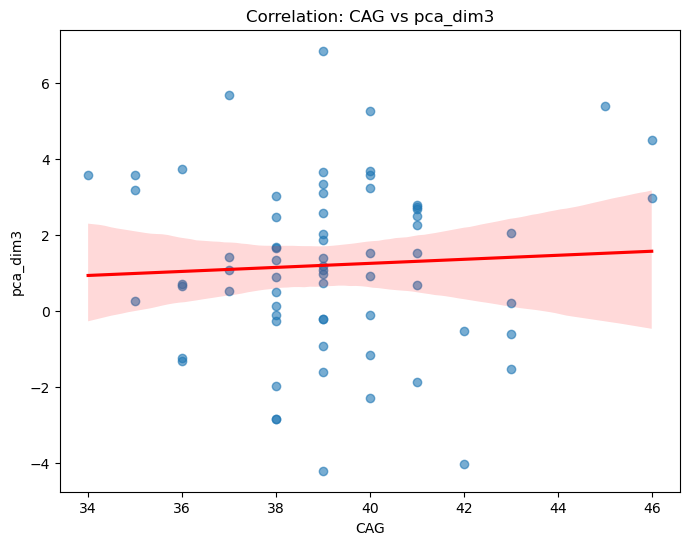

In [217]:
############################  scatter plot of correlations  ############################
cur_data = cur_info.copy()  ## cur_info defined above
cur_data_patient = cur_data[cur_data['SCA'] != 0]

class_variable = 'CAG'  # Independent Variable (X)
curX = 'pca_dim3' #'iso_dim1_neig5' # Dependent Variable (Y)

# Use regplot to get the scatter points PLUS a regression line
plt.figure(figsize=(8, 6))
sns.regplot(data=cur_data_patient, x=class_variable, y=curX, 
            scatter_kws={'alpha':0.6}, 
            line_kws={'color':'red'})

# Dynamic title based on your variables
plt.title(f'Correlation: {class_variable} vs {curX}')

#curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_Calc_SCA2_isoDim3Neig5_Manhattan_Scatter.png'
curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_FPOCalCuLEFT_SCA2_pcaDim3_CAG_Scatter.png'
print(f"Saving to: {curPlotName}")

# Uncomment these to save
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.show() # Recommended to see it before closing
#plt.close()

In [118]:
#########################  test read before boxplot of different Champollion results  #########################

inName_projAtril = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
         fr'\Atril_Biosca_Cermoi_pca_with_DB_INFO_save_withoutPostfix\{curRegion}_pca_2AtrilToRest_INFO.csv')
inName_projUKB = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
         fr'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2_UKBToRest_INFO.csv')

cur_info_projAtril = pd.read_csv(inName_projAtril,index_col=0,header=0)
cur_info_projUKB = pd.read_csv(inName_projUKB,index_col=0,header=0)

print(cur_info_projAtril.index)
print(cur_info_projUKB.index)
print(cur_info_projAtril.columns)
print(cur_info_projUKB.columns)

#combined_pca_info = pd.merge(cur_info_projAtril, cur_info_projUKB, left_index=True, right_index=True, how='outer')
combined_pca_info = pd.concat([cur_info_projAtril, cur_info_projUKB])
print(combined_pca_info.columns)
print(len(combined_pca_info))

Index(['001015VJ', '001017VP', '001019DA', '001020HG', '001021CJ', '001022LM',
       '001025LJ', '001027RY', '001032SG', '001037GA', '001040BF', '001045PB',
       '001046CJ', '001049BD', '001054MP', '001055JC', '001057MB', '001058FG',
       '001059MV', '001060MJ', '001065BC', '001073PM', '001075HJ', '001079LP',
       '001085BN', '001086CP', '001091MR', '001099GL', '001100PY', '001101JO',
       '00001PJ', '00002PV', '00004PA', '00007OP', '00008CJ', '00009LN',
       '00011EG', '00012BM', '00017ML', '00019RP', '00020CT', '00022DA',
       '00023EA', '00025AY', '00026AD', '00027EF', '00029DP', '00030CA',
       '00031CP', '00032DL', '00036DC', '00037CI', '00039OV', '0010001OP',
       '0010002MV', '0010003CJ', '0010004HV', '0010005BC', '0010006OG',
       '0010007MA', '0010008CT', '0010009BJ', '0010010DM', '0010011CP',
       '0010012MC', '0010013AN', '0010014MM', '0010015BV', '0010016VP',
       '0010017MD', '0010018RE', '0010019MM', '0010020PA', '0010021MA',
       '0010022MB', '00

C:\Users\joyca\AppData\Local\Temp\ipykernel_23384\2382992519.py:7: DtypeWarning: Columns (0,7,8,18) have mixed types. Specify dtype option on import or set low_memory=False.
  cur_info_projUKB = pd.read_csv(inName_projUKB,index_col=0,header=0)


C:\Users\joyca\AppData\Local\Temp\ipykernel_23384\4190568949.py:8: DtypeWarning: Columns (0,7,8,18) have mixed types. Specify dtype option on import or set low_memory=False.
  cur_info_projUKB = pd.read_csv(inName_projUKB,index_col=0,header=0)
C:\Users\joyca\AppData\Local\Temp\ipykernel_23384\4190568949.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Duplicate IDs found: 48
C:\B_projWIP\proj_ataxia\Champollion\Plots\Champollion_FPOCalCu_SCA2_pcaDim3_proj_Atril_UKB_ToSca2Ctl.png


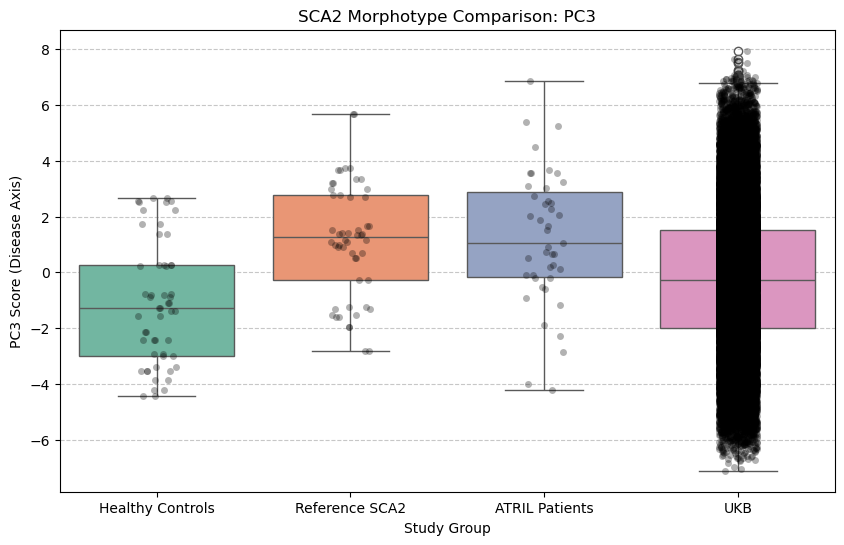

In [140]:
############################  boxplot for SCA of original pca and various projections  ############################
# The comparison of where the control and patient are located in the SCA2+control space
# Also plot the projection of the Atril patients, to see if it agrees with the patients above
# In addition, plot the projection of the UKB controls into the pca SCA2+control embedding, to see if there's abatch effect

# loading the original + projection data
inName_projAtril = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
         fr'\Atril_Biosca_Cermoi_pca_with_DB_INFO_save_withoutPostfix\{curRegion}_pca_2AtrilToRest_INFO.csv')
inName_projUKB = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
         fr'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2_UKBToRest_INFO.csv')
cur_info_projAtril = pd.read_csv(inName_projAtril,index_col=0,header=0)
cur_info_projUKB = pd.read_csv(inName_projUKB,index_col=0,header=0)
combined_pca_INFO = pd.concat([cur_info_projAtril, cur_info_projUKB])




#combined_pca_INFO = cur_info.copy()  

#######################  Define the logic for the three groups  #########################
combined_pca_INFO['PlotGroup'] = 'Other'    # Start with a column of 'Other' or NaNs

# Group A: ATRIL (Patients)
mask_atril = combined_pca_INFO['CodeICM'] == 'ATRIL'
combined_pca_INFO.loc[mask_atril, 'PlotGroup'] = 'ATRIL Patients'
# Group B: Controls (SCA == 0)
mask_control = combined_pca_INFO['SCA'] == 0
combined_pca_INFO.loc[mask_control, 'PlotGroup'] = 'Healthy Controls'
# Group C: Reference SCA2 (SCA == 2 but not ATRIL)
mask_ref_sca2 = (combined_pca_INFO['SCA'] == 2) & (combined_pca_INFO['CodeICM'] != 'ATRIL')
combined_pca_INFO.loc[mask_ref_sca2, 'PlotGroup'] = 'Reference SCA2'

# Group D: UKB (Controls)
mask_ukb = combined_pca_INFO['CodeICM'] == 'UKB'
combined_pca_INFO.loc[mask_ukb, 'PlotGroup'] = 'UKB'

######################  Filter out the 'Other' rows if any remain  ######################
plot_df = combined_pca_INFO[combined_pca_INFO['PlotGroup'] != 'Other'].copy()



#####################  Removing duplicates before plotting  ######################
print(f"Duplicate IDs found: {plot_df.index.duplicated().sum()}")
# Keep only the first occurrence of each ID
plot_df = plot_df[~plot_df.index.duplicated(keep='first')]



#################################  Create the Boxplot  ###################################
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_df, 
    x='PlotGroup', 
    y='pca_dim3', 
#    order=['Healthy Controls', 'Reference SCA2', 'ATRIL Patients'], # Controls the sequence
#    order=['Healthy Controls', 'Reference SCA2', 'UKB'], # Controls the sequence
    order=['Healthy Controls', 'Reference SCA2', 'ATRIL Patients', 'UKB'], # Controls the sequence       
#    order=['Healthy Controls', 'UKB', 'Reference SCA2', 'ATRIL Patients'], # Controls the sequence    
    palette='Set2'
)

##################  Add individual points on top to see the distribution (stripplot)  ####################
sns.stripplot(
    data=plot_df, 
    x='PlotGroup', 
    y='pca_dim3', 
#    order=['Healthy Controls', 'Reference SCA2', 'ATRIL Patients'],
#    order=['Healthy Controls', 'Reference SCA2', 'UKB'], 
    order=['Healthy Controls', 'Reference SCA2', 'ATRIL Patients', 'UKB'],     
#    order=['Healthy Controls', 'UKB', 'Reference SCA2', 'ATRIL Patients'],       
    color='black', 
    alpha=0.3
)
plt.title('SCA2 Morphotype Comparison: PC3')
plt.ylabel('PC3 Score (Disease Axis)')
plt.xlabel('Study Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
#plt.show()


curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_FPOCalCu_SCA2_pcaDim3_proj_Atril_UKB_ToSca2Ctl.png'
print(curPlotName)
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
#plt.close()

In [180]:
#########  Test statistically the batch effect between the controls of UKB and SCA2 (Biosca+Cermoi)  #########
#########  Test if the UKB projection is different to the SCA2 patients (Biosca+Cermoi)  ##########

# loading the original + projection data
inName_projAtril = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
         fr'\Atril_Biosca_Cermoi_pca_with_DB_INFO_save_withoutPostfix\{curRegion}_pca_2AtrilToRest_INFO.csv')
inName_projUKB = (rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion'
         fr'\Atril_Biosca_Cermoi_pca_with_DB_INFO\{curRegion}_pca_2_UKBToRest_INFO.csv')
cur_info_projAtril = pd.read_csv(inName_projAtril,index_col=0,header=0)
cur_info_projUKB = pd.read_csv(inName_projUKB,index_col=0,header=0)
combined_pca_INFO = pd.concat([cur_info_projAtril, cur_info_projUKB])

# selection of different groups
selectCol = 'pca_dim3'
ATRILprojectionControls = combined_pca_INFO.loc[
    combined_pca_INFO['CodeICM'] == 'ATRIL',
    selectCol]
UKBprojectionControls = combined_pca_INFO.loc[
    combined_pca_INFO['CodeICM'] == 'UKB',
    selectCol]
SCA2controls = combined_pca_INFO.loc[
    combined_pca_INFO['SCA'] == 0,
    selectCol]
SCA2patients = combined_pca_INFO.loc[
    (combined_pca_INFO['SCA'] == 2) & 
    (combined_pca_INFO['CodeICM'] != 'ATRIL'),
    selectCol]
#print(SCA2patients.index)
#SCA2patients.head
####################################  t-test  #####################################
from scipy.stats import ttest_ind

#x = UKBprojectionControls.dropna()
x = SCA2patients.dropna()
y = SCA2controls.dropna()
#y = SCA2patients.dropna()

# use Welch’s t-test, more robust when variance differ
t_stat, p_val = ttest_ind(x, y, equal_var=False)

print(f"X mean: {x.mean():.3f}")
print(f"Y mean: {y.mean():.3f}")
print(f"t = {t_stat:.3f}, p = {p_val:.10f}")

##############################  Cohen's D for effect size  ################################ 
def cohens_d(x, y):
    x = np.array(x.dropna())
    y = np.array(y.dropna())
    nx = len(x)
    ny = len(y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    # pooled standard deviation
    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / (nx + ny - 2)
    )
    d = (mean_x - mean_y) / pooled_std
    return d

d = cohens_d(x,y)
print(f"Cohen's d: {d:.3f}")

X mean: 1.149
Y mean: -1.107
t = 5.459, p = 0.0000003287
Cohen's d: 1.059


C:\Users\joyca\AppData\Local\Temp\ipykernel_23384\4114364431.py:10: DtypeWarning: Columns (0,7,8,18) have mixed types. Specify dtype option on import or set low_memory=False.
  cur_info_projUKB = pd.read_csv(inName_projUKB,index_col=0,header=0)


C:\B_projWIP\proj_ataxia\Champollion\Plots\Champollion_FPOCalCu_SCA2_NormativeSpace_UKB_Ctl_pat.png


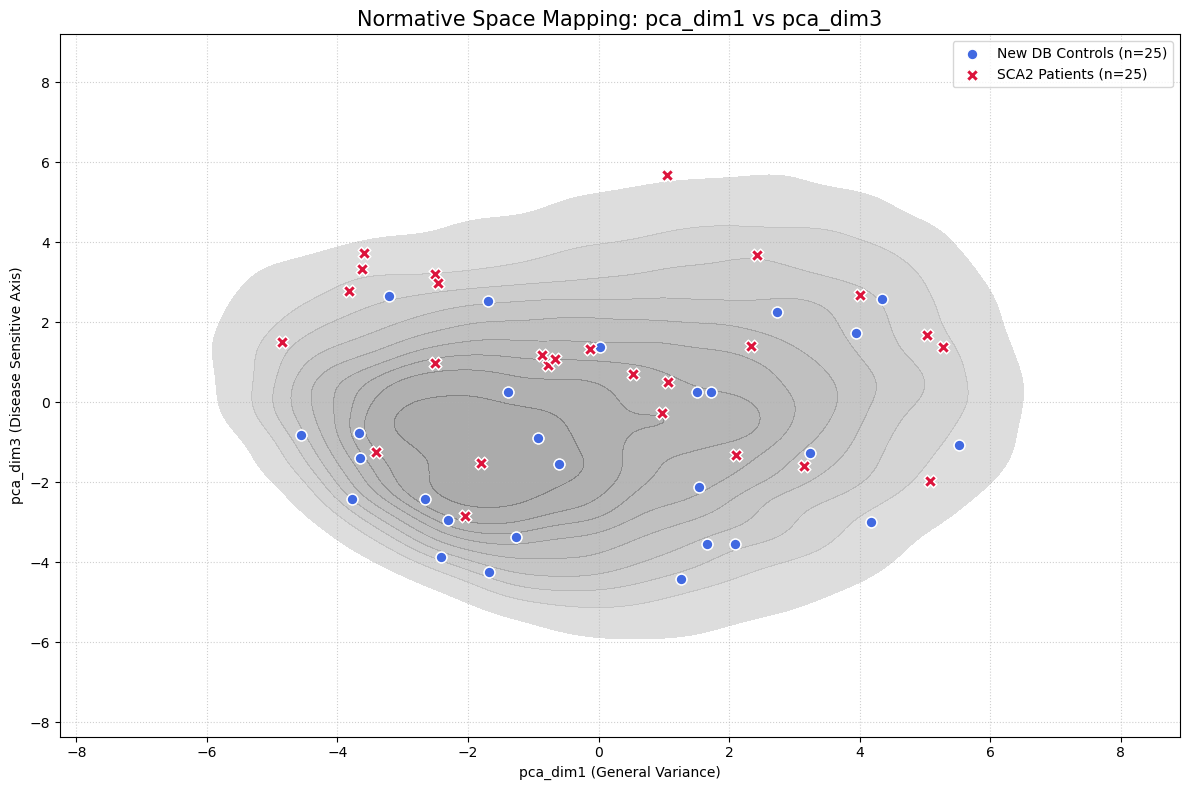

In [192]:
################################  Normative space mapping  ######################################

selectCol = ['pca_dim1','pca_dim3']
ATRILprojectionControls = combined_pca_INFO.loc[
    combined_pca_INFO['CodeICM'] == 'ATRIL',
    selectCol]
UKBprojectionControls = combined_pca_INFO.loc[
    combined_pca_INFO['CodeICM'] == 'UKB',
    selectCol]
SCA2controls = combined_pca_INFO.loc[
    combined_pca_INFO['SCA'] == 0,
    selectCol]
SCA2patients = combined_pca_INFO.loc[
    (combined_pca_INFO['SCA'] == 2) & 
    (combined_pca_INFO['CodeICM'] != 'ATRIL'),
    selectCol]

def plot_normative_space(combined_df, x_dim='pca_dim1', y_dim='pca_dim3',curPlotName=''):
    plt.figure(figsize=(12, 8))
    
    # 1. Split the data
    #ukb_data = combined_df[combined_df['CodeICM'] == 'UKB']
    ukb_data = UKBprojectionControls
    #new_controls = combined_df[combined_df['PlotGroup'] == 'Healthy Controls']
    new_controls = SCA2controls 
    #patients = combined_df[combined_df['PlotGroup'] == 'ATRIL Patients']
    patients = SCA2patients
    
    # 2. Plot the 40k UKB as a subtle "Density Cloud"
    # This shows the 'Expected Range' without cluttering the plot
    sns.kdeplot(
        data=ukb_data, x=x_dim, y=y_dim, 
        fill=True, thresh=0.05, levels=10, 
        color='lightgray', alpha=0.5, label='UKB Population (40k)'
    )
    
    # 3. Overlay the New Controls (Blue)
    plt.scatter(
        new_controls[x_dim], new_controls[y_dim], 
        color='royalblue', edgecolor='white', s=60, 
        label='New DB Controls (n=25)', zorder=3
    )
    
    # 4. Overlay the Patients (Red)
    plt.scatter(
        patients[x_dim], patients[y_dim], 
        color='crimson', edgecolor='white', s=80, marker='X',
        label='SCA2 Patients (n=25)', zorder=4
    )
    
    # Formatting
    plt.title(f'Normative Space Mapping: {x_dim} vs {y_dim}', fontsize=15)
    plt.xlabel(f'{x_dim} (General Variance)')
    plt.ylabel(f'{y_dim} (Disease Sensitive Axis)')
    plt.legend(frameon=True, loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()

    print(curPlotName)
    plt.savefig(curPlotName, dpi=300, bbox_inches='tight')
    
    plt.show()

# To run plot:
curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\Champollion_FPOCalCu_SCA2_NormativeSpace_UKB_Ctl_pat.png'
plot_normative_space(combined_pca_info, x_dim='pca_dim1', y_dim='pca_dim3',curPlotName=curPlotName)

In [ ]:
##############################   WIP: automatic parameter selection  ################################

In [ ]:
##########  WIP....check the reconstruction error of the three types of distances  ##########

metrics = ['euclidean', 'manhattan', 'cosine']
for m in metrics:
    result_df = perform_isomap(data_df, 2, 5, metric=m)
    error = result_df.attrs['reconstruction_error']
    print(f"Metric: {m} | Reconstruction Error: {error:.4f}")

In [ ]:
###################  construct latent_dict  ####################
inPath = rf"\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_iso_u"
region_list = [] # the 15 relevant regions

In [ ]:
#######################  parameter selection  ########################

regions_list = ['FPO-SCu-ScCal_right_name07-15-26--174_embeddings_iso_u']
results = {}

for region in regions_list:
    # 1. Get data for this region (Subjects x 32)
    data = latent_dict[region] 
    
    # 2. Secondary Embedding (Double Embedding)
    primary_dist = pairwise_distances(data, metric='cosine')
    secondary_dist = pairwise_distances(primary_dist, metric='euclidean')
    
    # 3. Test PCA (PCoA) vs Isomap
    pca_coords = PCA(n_components=2).fit_transform(secondary_dist)
    iso_coords = Isomap(n_neighbors=10, metric='precomputed').fit_transform(secondary_dist)
    
    # 4. Score them
    score_pca = silhouette_score(pca_coords, labels)
    score_iso = silhouette_score(iso_coords, labels)
    
    # 5. Automated Choice
    if score_iso > score_pca:
        final_coords = iso_coords
        method_used = "Isomap"
    else:
        final_coords = pca_coords
        method_used = "PCA"
        
    results[region] = {'coords': final_coords, 'method': method_used, 'score': max(score_pca, score_iso)}